In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 2. Load the Excel dataset
file_path = "C:\\Users\\User\\Desktop\\intern2\\ML_new.xlsx"
df = pd.read_excel(file_path)

# 3. Check for missing values and drop them
print("Missing values:\n", df.isnull().sum())
df.dropna(inplace=True)  # You could use df.fillna() instead, if needed

# 4. Define input features and target variable
X = df.drop(columns=['Efficiency'])
y = df['Efficiency']

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# SVR works better with scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVR model
svr_model = SVR(kernel='rbf')  # Try 'linear' or 'poly' as alternatives
svr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate performance
print("\nSVR Results:")
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))



# ------------------- 7. Random Forest -------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

# ------------------- 8. XGBoost -------------------
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Results:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))


Missing values:
 Thickness                  0
Defect density             0
Band gap                   0
Electron affinity          0
Dielectric permittivity    0
CB effective DOS           0
VB effective DOS           0
Acceptor density           0
Efficiency                 0
dtype: int64

SVR Results:
R2 Score: 0.9145459590603989
MSE: 12.940306404719767
MAE: 2.6292673707492993

Random Forest Results:
R2 Score: 0.9997853923936744
MSE: 0.032498032300196746
MAE: 0.09307505851363396

XGBoost Results:
R2 Score: 0.9999391404663824
MSE: 0.009215959877388413
MAE: 0.051140506443509245


Visualize Predictions

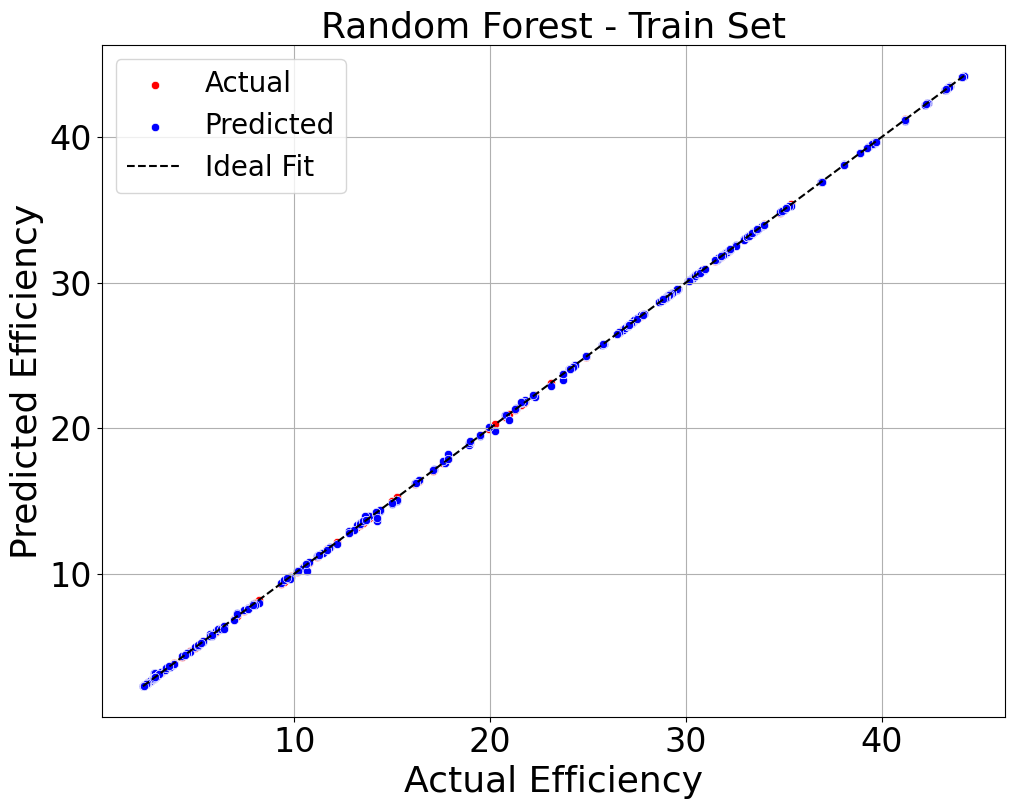

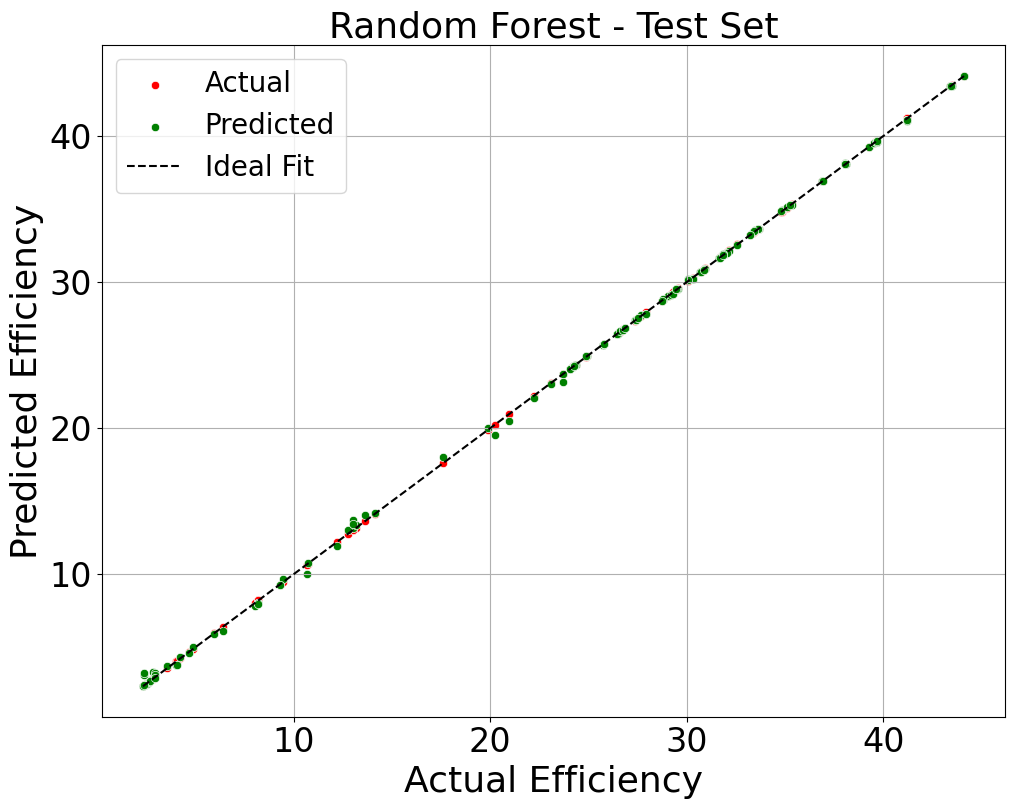

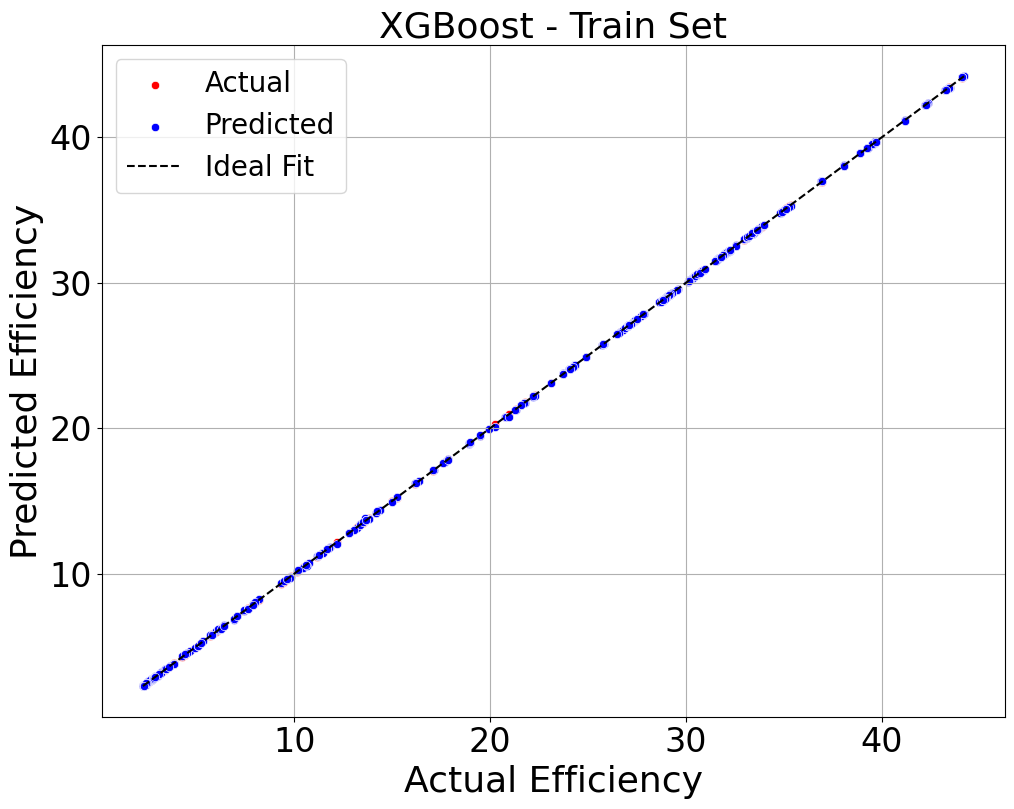

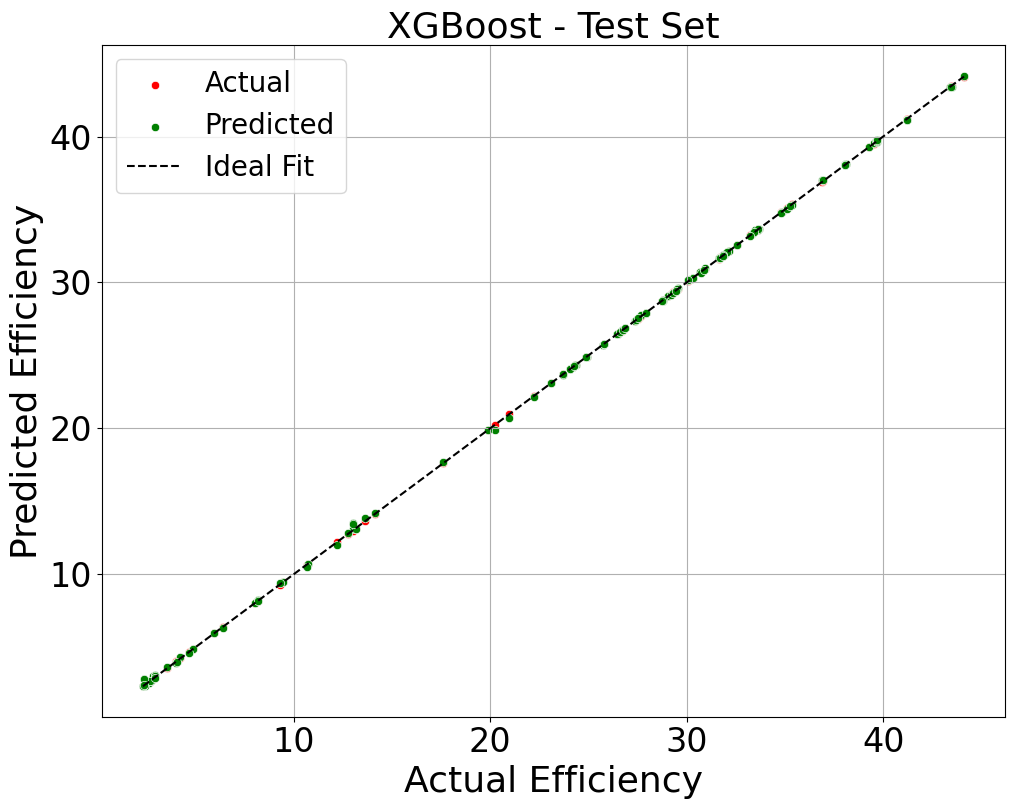

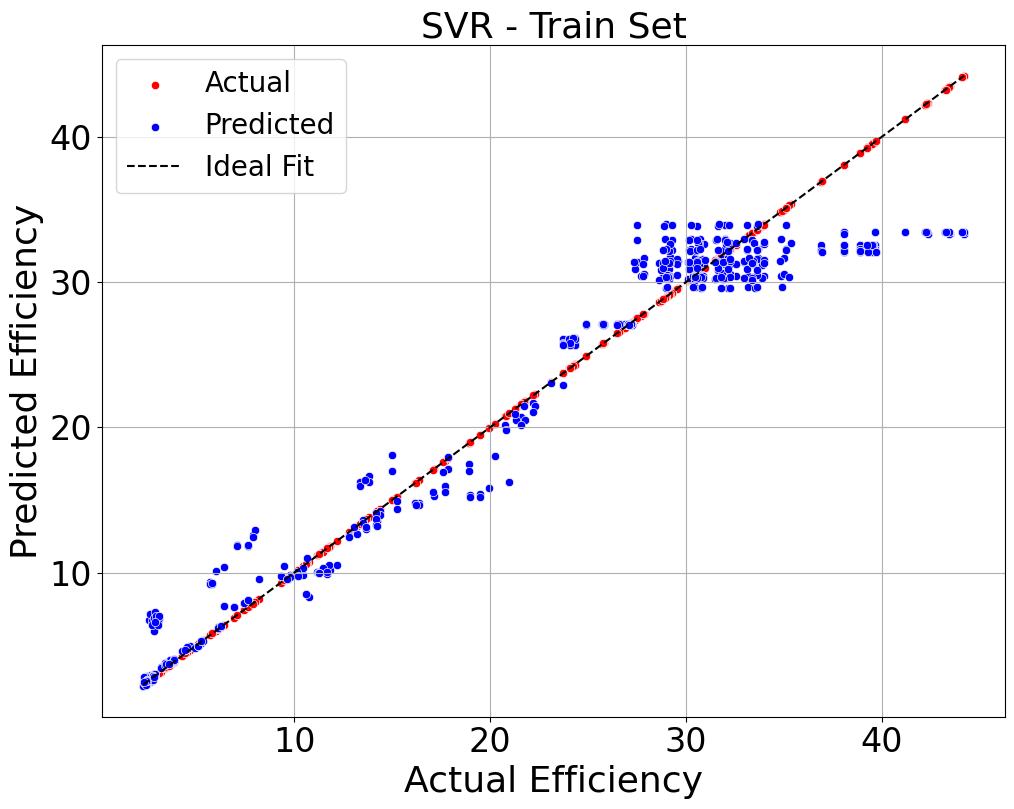

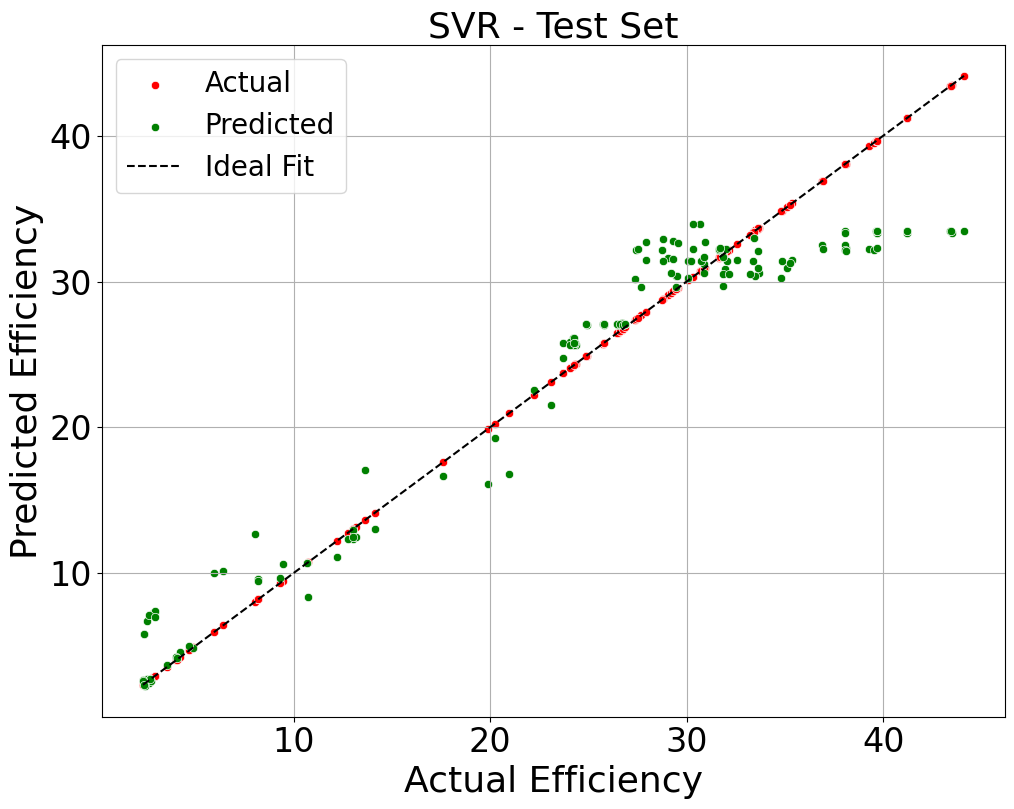

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recalculate train predictions if needed
y_pred_rf_train = rf_model.predict(X_train)
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_svr_train = svr_model.predict(X_train_scaled)  # SVR uses scaled features

models = {
    'Random Forest': (y_train, y_pred_rf_train, y_test, y_pred_rf),
    'XGBoost': (y_train, y_pred_xgb_train, y_test, y_pred_xgb),
    'SVR': (y_train, y_pred_svr_train, y_test, y_pred_svr),
}

for model_name, (y_tr, y_tr_pred, y_te, y_te_pred) in models.items():
    # Train Set Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_tr, y=y_tr, color='red', label='Actual')
    sns.scatterplot(x=y_tr, y=y_tr_pred, color='blue', label='Predicted')
    plt.plot([y_tr.min(), y_tr.max()], [y_tr.min(), y_tr.max()], 'k--', label='Ideal Fit')
    plt.xlabel("Actual Efficiency", fontsize=26)
    plt.ylabel("Predicted Efficiency", fontsize=26)
    plt.title(f"{model_name} - Train Set", fontsize=26)
    plt.legend(loc='upper left', fontsize=20)
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.show()

    # Test Set Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_te, y=y_te, color='red', label='Actual')
    sns.scatterplot(x=y_te, y=y_te_pred, color='green', label='Predicted')
    plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'k--', label='Ideal Fit')
    plt.xlabel("Actual Efficiency", fontsize=26)
    plt.ylabel("Predicted Efficiency", fontsize=26)
    plt.title(f"{model_name} - Test Set", fontsize=26)
    plt.legend(loc='upper left', fontsize=20)
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.show()


XGBoost

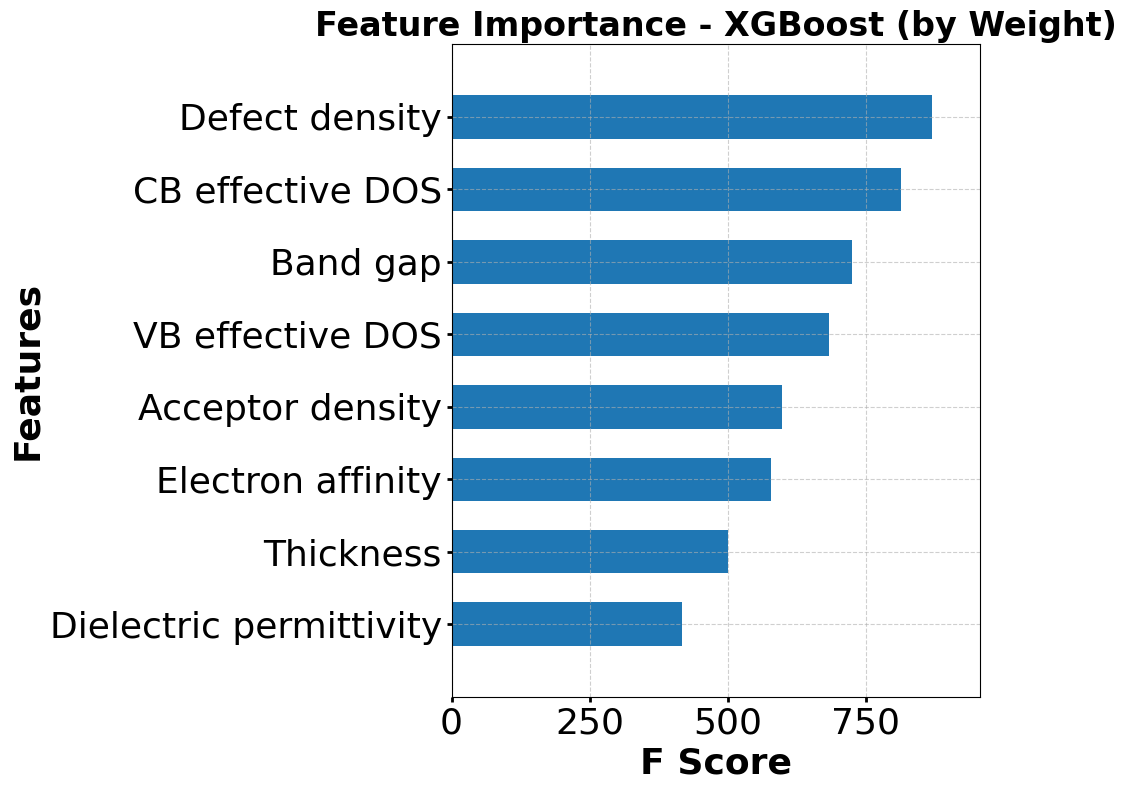

In [4]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Plot feature importance (by weight) with enhanced styling
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(
    xgb_model,
    importance_type='weight',
    show_values=False,
    ax=ax,
    height=0.6,
)

# Customize fonts and layout
ax.set_title("Feature Importance - XGBoost (by Weight)", fontsize=24, fontweight='bold')
ax.set_xlabel("F Score", fontsize=26, fontweight='bold')
ax.set_ylabel("Features", fontsize=26, fontweight='bold')
ax.tick_params(axis='x', labelsize=26, width=2)
ax.tick_params(axis='y', labelsize=26, width=2)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
